In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
def f(x):
    return 3*x**2 -4*x + 5

In [3]:
type(f(3.0))

float

In [4]:
f(3.0)

20.0

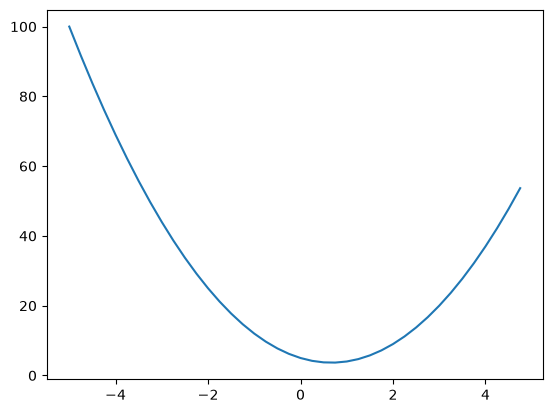

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [6]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [7]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.00001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
a+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.9999699999999994
slope -3.000000000064062


In [9]:
class Value:

    def __init__(self, value, _children = (), op ='', label = ''):
        self.data = value
        self._prev = _children
        self._op = op
        self.label = label
        self.grad = 0
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
        
    def tanh(self):
        x = self.data
        out = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        return Value(out, (self,), op ='tanh')
        

In [10]:
a = Value(2.0)

In [11]:
a.data

2.0

In [12]:
print(a)

Value(data=2.0)


In [13]:
b = Value(3.0)
a + b

Value(data=5.0)

In [14]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label ='b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L =  d*f
L
L.label = 'L'

In [15]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label ='b')
c = Value(10.0, label = 'c')
e = a + b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(2.0, label = 'f')
L1 =  d*f
L1
L1.label = 'L'

In [16]:
a*b

Value(data=-6.0)

In [17]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label ='b')
c = Value(10.0, label = 'c')
e = a + b; e.label = 'e'
e.data+=0.00001
d = e + c; d.label = 'd'
f = Value(2.0, label = 'f')
L2 =  d*f
L2
L2.label = 'L'

In [18]:
(L2.data -L1.data)/0.00001

1.9999999999242843

In [19]:
d._prev

(Value(data=-0.99999), Value(data=10.0))

In [20]:
f._prev

()

In [21]:
d._op

'+'

In [22]:
f._op

''

In [23]:
d.label

'd'

In [24]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

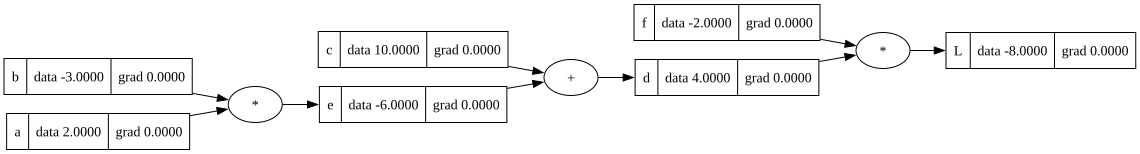

In [25]:
draw_dot(L)

In [26]:
L.grad = 1.0

In [27]:
# dl/dd = f , dl/df = d 
d.grad = f.data
f.grad = d.data

In [28]:
e.grad = 1*d.grad
c.grad = 1*d.grad

In [29]:
a.grad = b.data*e.grad
b.grad = a.data*e.grad

In [30]:

def lol():
  
  h = 0.000001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  a.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

6.000000000838668


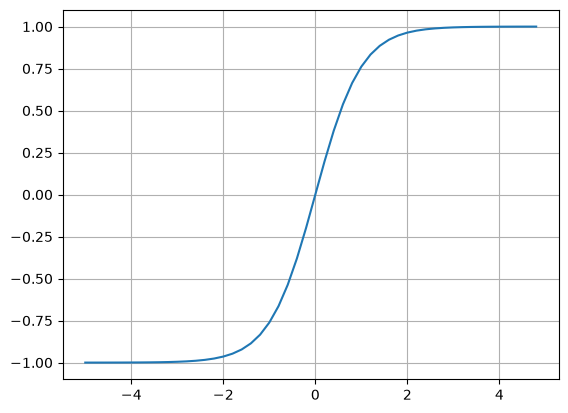

In [31]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [32]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

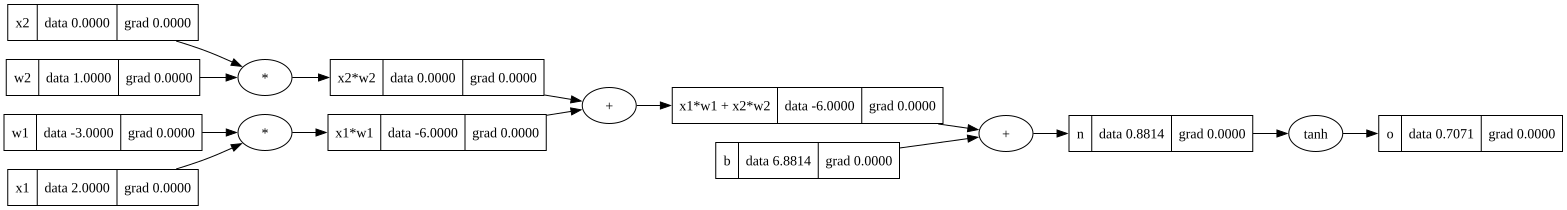

In [33]:
draw_dot(o)

In [34]:
o.grad = 1.0

In [35]:
n.grad = 1.0 - o.data**2

In [36]:
x1w1x2w2.grad = 1.0* n.grad
b.grad = 1.0*n.grad

In [37]:
x1w1.grad = 1.0* x1w1x2w2.grad
x2w2.grad = 1.0* x1w1x2w2.grad


In [38]:
x1.grad = w1.data*x1w1.grad
w1.grad = x1.data*x1w1.grad

In [39]:
x2.grad = w2.data*x2w2.grad
w2.grad = x2.data*x2w2.grad

## now will apply automated backpropogration

In [40]:
class Value:

    def __init__(self, value, _children = (), op ='', label = ''):
        self.data = value
        self._prev = _children
        self._op = op
        self.label = label
        self.grad = 0
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad+= 1.0*out.grad
            other.grad+= 1.0*out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad+= other.data*out.grad
            other.grad+= self.data*out.grad
        out._backward = _backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), op ='tanh')
        def _backward():
            self.grad+= (1-t**2)*out.grad
        out._backward = _backward
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        
        
        

In [41]:
a = Value(-2.6); a.label = 'a'

In [42]:
b = Value(3); b.label = 'b'
c = a * b; c.label = 'c'

In [43]:
o = c.tanh()

In [44]:
o.grad = 1

In [45]:
o._backward()

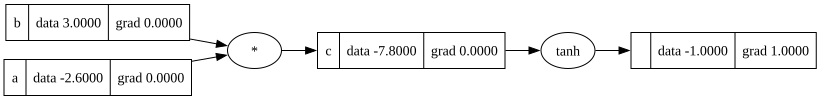

In [46]:
draw_dot(o)

In [47]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

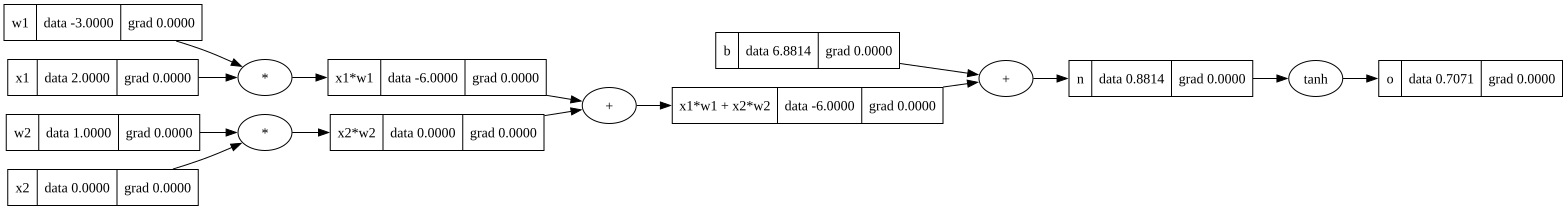

In [48]:
draw_dot(o)

In [49]:
o.grad = 1.0

In [50]:
o._backward()

In [51]:
n._backward()

In [52]:
x1w1x2w2._backward()

In [53]:
x2w2._backward()

In [54]:
x1w1._backward()

In [55]:
b.grad

0.4999999999999999

### topological sort to not call each node backward fucntion from root-> leaf ordering we can get through topological sort

In [56]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [57]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

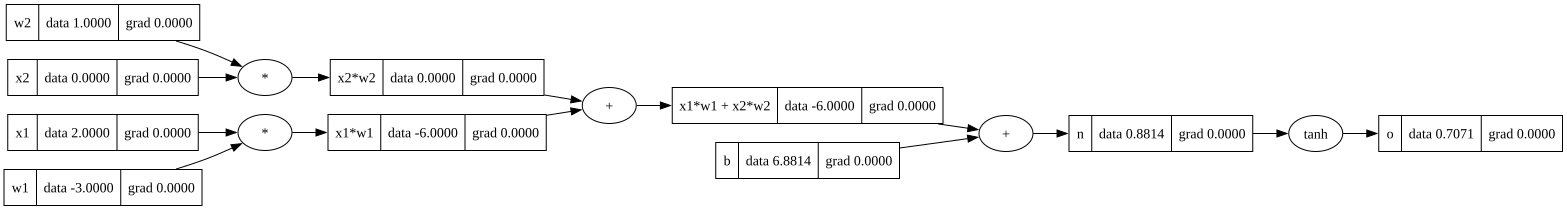

In [58]:
draw_dot(o)

In [59]:
o.backward()

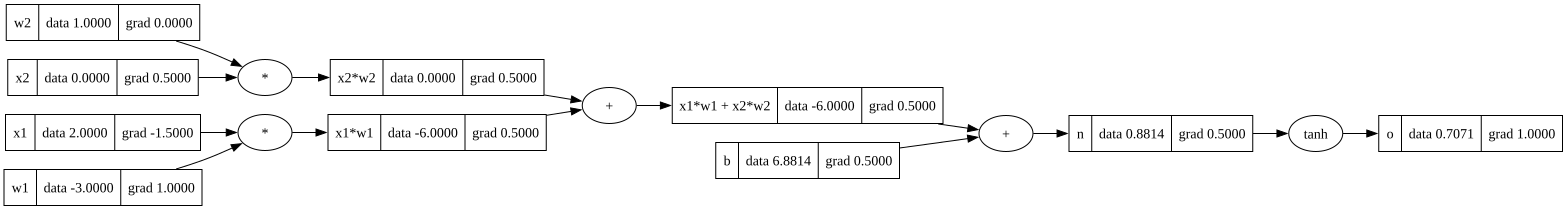

In [60]:
draw_dot(o)

### gradient accumulation bug

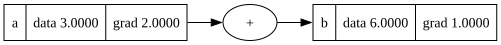

In [61]:
a = Value(3.0, label ='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

### afterr bug fix graient should accumulate if node used more than one time

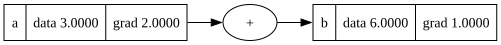

In [73]:
a = Value(3.0, label ='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

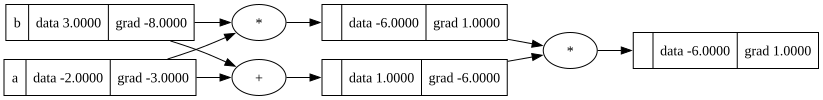

In [74]:
a = Value(-2.0, label ='a')
b = Value(3.0, label ='b')
d = a*b
e = a+b
f = d*e

f.backward()
draw_dot(f)

In [75]:
### final addtion of division , subtraction , power

In [76]:
import math

class Value:
    
    def __init__(self, value, _children = (), op ='', label = ''):
        self.data = value
        self._prev = _children
        self._op = op
        self.label = label
        self.grad = 0
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad+= 1.0*out.grad
            other.grad+= 1.0*out.grad
        out._backward = _backward
        return out
        
    def __radd__(self,other):
        return self + other
        
    def __neg__(self):
        return self*-1
       
    def __sub__(self,other):
        return self + (-other)
        
    def __rsub__(self,other):
        return -self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad+= other.data*out.grad
            other.grad+= self.data*out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        return self*other

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = self *other**-1
        return out
        
    def __rtruediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other * (self ** -1)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)) ## supporting int/float for now
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other*(self.data**(other-1))*out.grad
            
        out._backward = _backward
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad+= out.data*out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), op ='tanh')
        def _backward():
            self.grad+= (1-t**2)*out.grad
        out._backward = _backward
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [77]:
t = Value(2.0); t.label = 't'

In [78]:
t-8

Value(data=-6.0)

In [79]:
t.backward()

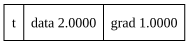

In [80]:
draw_dot(t)

In [81]:
t._prev

()

In [82]:
t + 6

Value(data=8.0)

In [83]:
t + 6

Value(data=8.0)

In [84]:
6 + t

Value(data=8.0)

In [85]:
6 + t

Value(data=8.0)

In [86]:
t*2

Value(data=4.0)

In [87]:
t*48

Value(data=96.0)

In [88]:
485*t

Value(data=970.0)

In [89]:
a = Value(4.0)
b = Value(3.0)

In [90]:
a/b
# a/b = a * (b**-1)

Value(data=1.3333333333333333)

In [91]:
a/6

Value(data=0.6666666666666666)

In [92]:
c = a**2
c.backward()

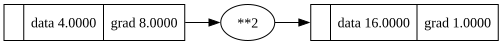

In [93]:
draw_dot(c)

In [94]:
b - 6

Value(data=-3.0)

In [95]:
6 -b

Value(data=3.0)

In [96]:
a - 6

Value(data=-2.0)

In [97]:
6 - a

Value(data=2.0)

In [98]:
y = Value(1.0, label ='y')
z = y.exp(); z.label = 'z'
out= z.tanh()


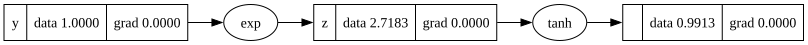

In [99]:
draw_dot(out)

In [100]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

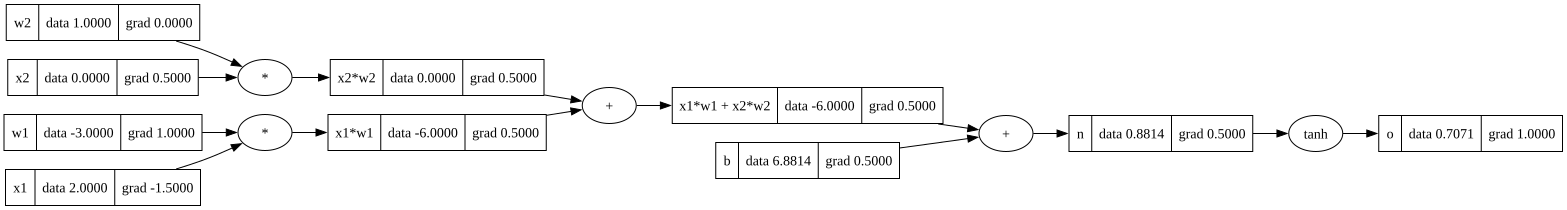

In [101]:
o.backward()
draw_dot(o)

In [102]:

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()

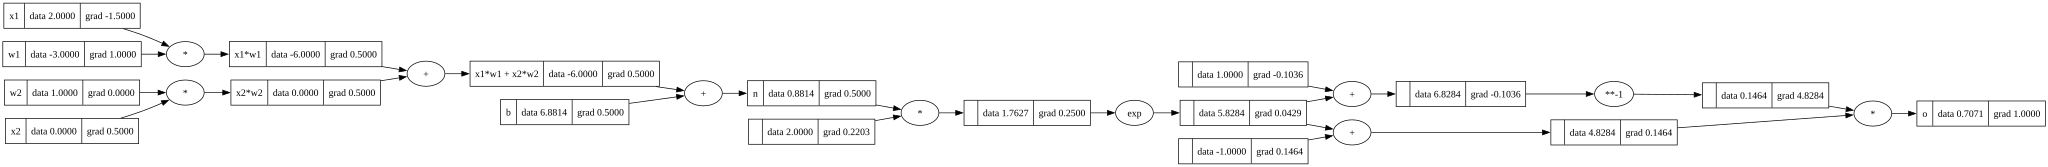

In [103]:
draw_dot(o)

In [104]:
x1/4.0

Value(data=0.5)

In [105]:
10.0/x1

Value(data=5.0)

In [106]:
## verification with pytorch

In [111]:
import torch

# Corrected using lowercase torch.tensor() to create scalar values properly
x1 = torch.tensor(2.0).double()                ; x1.requires_grad = True
x2 = torch.tensor(0.0).double()                ; x2.requires_grad = True
w1 = torch.tensor(-3.0).double()               ; w1.requires_grad = True
w2 = torch.tensor(1.0).double()                ; w2.requires_grad = True
b = torch.tensor(6.8813735870195432).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [113]:
x1.ndim

0

In [219]:
import random
class Neuron:

    def __init__(self, nin):
        self.weights = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.bias = Value(random.uniform(-1,1))
        
    def __call__(self,x):
        trf = sum((wi*xi for wi, xi in zip(self.weights, x)), self.bias)
        out = trf.tanh()
        return out
    def parameters(self):
        return self.weights + [self.bias]
        

In [220]:
n1 = Neuron(2)

In [221]:
n1.bias

Value(data=0.8506198974641366)

In [222]:
n1.weights

[Value(data=0.2906202489406806), Value(data=-0.8673626579484857)]

In [223]:
n1.parameters()

[Value(data=0.2906202489406806),
 Value(data=-0.8673626579484857),
 Value(data=0.8506198974641366)]

In [224]:
x = [2.0,3.0]
n2 = Neuron(2)

In [225]:
n2(x)

Value(data=-0.5604322676252146)

In [226]:
class Layer:
    def __init__(self, nin_each, nn_layer):
        self.neurons = [Neuron(nin_each) for _ in range(nn_layer)]
    def __call__(self, x):
        out = [node(x) for node in self.neurons]
        return out
    def parameters(self):
        p = [p for n in self.neurons for p in n.parameters()]
        return p

In [227]:
l = Layer(2,3)
l(x)

[Value(data=-0.8780389262354221),
 Value(data=-0.8848131542420598),
 Value(data=-0.9122253607987348)]

In [228]:
len(l.parameters())

9

In [237]:
class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x[0] if len(x)==1 else x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [246]:
n = MLP(2, [2,1])

In [247]:
xs = [
  [2.0, 3.0],
  [3.0, -1.0],
  [0.5, 1.0],
  [1.0, 1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [248]:
epochs = 20

In [249]:
for epoch in range(epochs):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(epoch, loss.data)
  

0 5.83912445310119
1 3.8592681614562436
2 2.90925963674917
3 2.5661936790228252
4 2.3909412359546183
5 2.2661783175892847
6 2.1600011255972156
7 2.0624287005617363
8 1.9703846910941767
9 1.883841515515039
10 1.8034629238219644
11 1.7296442857776615
12 1.6674658327057135
13 1.6643252071212444
14 2.088264126810755
15 3.4982149746135303
16 1.7900901259368935
17 2.241162163012374
18 2.5845577584071195
19 2.4793597378596877


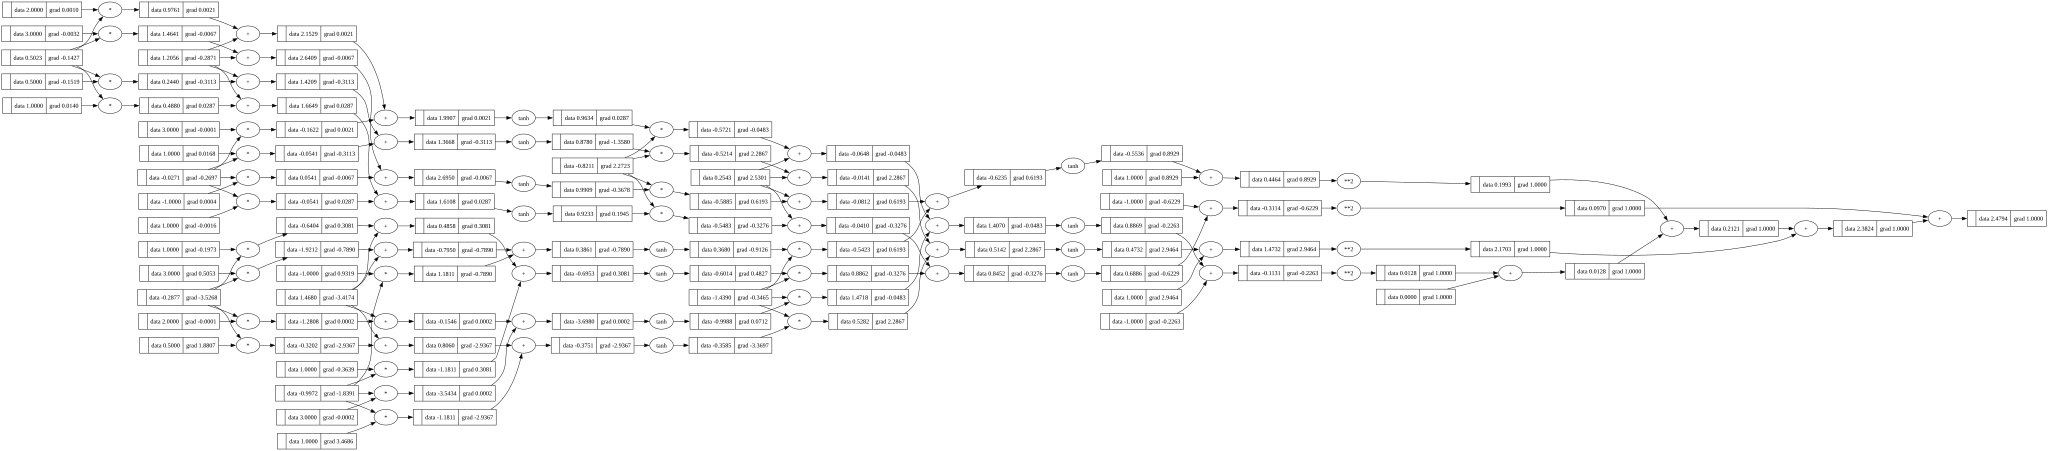

In [250]:
draw_dot(loss)